****First project of my machine learning journey****

*included all the basic libraries*

In [138]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from  plotly.offline import iplot
import cufflinks as cf

**Fetched IPL data to perform the operaction**

In [139]:
df=pd.read_csv('matches.csv')


**Got some needed information of file before manipulating the data**

In [140]:
df.shape


(39, 23)

In [141]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   match_id             39 non-null     int64  
 1   date                 39 non-null     str    
 2   venue                39 non-null     str    
 3   team1                39 non-null     str    
 4   team2                39 non-null     str    
 5   stage                39 non-null     str    
 6   toss_winner          39 non-null     str    
 7   toss_decision        39 non-null     str    
 8   first_ings_score     38 non-null     float64
 9   first_ings_wkts      38 non-null     float64
 10  second_ings_score    38 non-null     float64
 11  second_ings_wkts     38 non-null     float64
 12  match_result         39 non-null     str    
 13  match_winner         38 non-null     str    
 14  wb_runs              15 non-null     float64
 15  wb_wickets           22 non-null     float64
 16  bal

In [142]:
df.describe()

,match_id,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,wb_runs,wb_wickets,balls_left,highscore
count,39.000000,38.000000,38.000000,38.000000,38.000000,15.000000,22.000000,38.000000,38.000000
mean,20.000000,190.526316,6.289474,175.500000,6.052632,41.666667,5.772727,10.684211,79.447368
std,11.401754,39.394565,2.470451,39.747684,2.670635,30.658643,1.477830,15.773918,24.521031
min,1.000000,75.000000,2.000000,77.000000,1.000000,1.000000,3.000000,0.000000,34.000000
25%,10.500000,159.750000,4.250000,159.250000,4.000000,20.500000,5.000000,0.250000,60.750000
50%,20.000000,197.000000,6.000000,180.000000,5.000000,40.000000,6.000000,6.000000,77.500000
75%,29.500000,215.000000,8.000000,203.750000,8.000000,55.500000,6.000000,12.000000,91.750000
max,39.000000,264.000000,10.000000,265.000000,10.000000,103.000000,9.000000,81.000000,152.000000


**cleaning the data which have null value**

In [143]:
df.isna().count().head(3)

match_id    39
date        39
venue       39
dtype: int64

In [144]:
df.head(2)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_winner,wb_runs,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
0,1,"March 28, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,SRH,League,RCB,Bowl,201.0,9.0,...,RCB,NaN,6.0,26.0,Jacob Duffy,Ishan Kishan,80.0,Jacob Duffy,3--22,No
1,2,"March 29, 2026","Wankhede Stadium, Mumbai",MI,KKR,League,MI,Bowl,220.0,4.0,...,MI,NaN,6.0,5.0,Shardul Thakur,Ryan Rickelton,81.0,Shardul Thakur,3--39,No


In [145]:
df.drop('wb_runs',axis=1,inplace=True)

In [146]:
df.head(3)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_result,match_winner,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
0,1,"March 28, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,SRH,League,RCB,Bowl,201.0,9.0,...,completed,RCB,6.0,26.0,Jacob Duffy,Ishan Kishan,80.0,Jacob Duffy,3--22,No
1,2,"March 29, 2026","Wankhede Stadium, Mumbai",MI,KKR,League,MI,Bowl,220.0,4.0,...,completed,MI,6.0,5.0,Shardul Thakur,Ryan Rickelton,81.0,Shardul Thakur,3--39,No
2,3,"March 30, 2026","Barsapara Stadium, Guwahati",RR,CSK,League,RR,Bowl,127.0,10.0,...,completed,RR,8.0,47.0,Nandre Burger,Vaibhav Sooryavanshi,52.0,Jofra Archer,2--19,No


In [148]:
df.dropna().head(3)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_result,match_winner,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
0,1,"March 28, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,SRH,League,RCB,Bowl,201.0,9.0,...,completed,RCB,6.0,26.0,Jacob Duffy,Ishan Kishan,80.0,Jacob Duffy,3--22,No
1,2,"March 29, 2026","Wankhede Stadium, Mumbai",MI,KKR,League,MI,Bowl,220.0,4.0,...,completed,MI,6.0,5.0,Shardul Thakur,Ryan Rickelton,81.0,Shardul Thakur,3--39,No
2,3,"March 30, 2026","Barsapara Stadium, Guwahati",RR,CSK,League,RR,Bowl,127.0,10.0,...,completed,RR,8.0,47.0,Nandre Burger,Vaibhav Sooryavanshi,52.0,Jofra Archer,2--19,No


**using  distribution plot to compare the quantitative values**

Text(0.5, 1.0, 'this chart shows comaprision between column data')

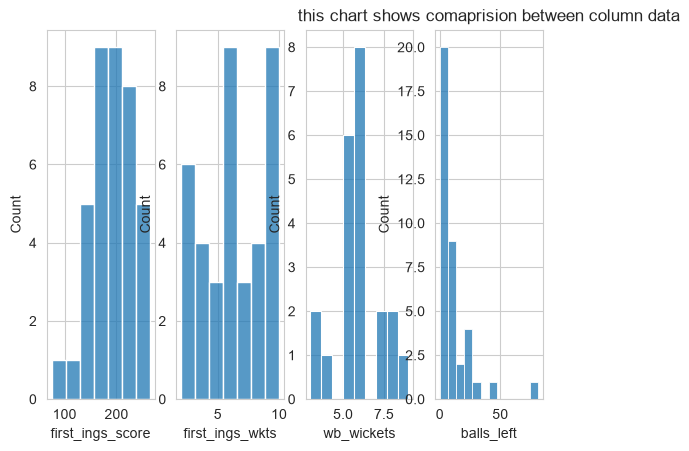

In [174]:
plt.subplot(1,4,1)
sns.histplot(df['first_ings_score'])
plt.subplot(1,4,2)
sns.histplot(df['first_ings_wkts'])
plt.subplot(1,4,3)
sns.histplot(df['wb_wickets'])
plt.subplot(1,4,4)
sns.histplot(df['balls_left'])
plt.title('this chart shows comaprision between column data')

Text(0.5, 1.0, 'jointplot compares all the quantitative value !')

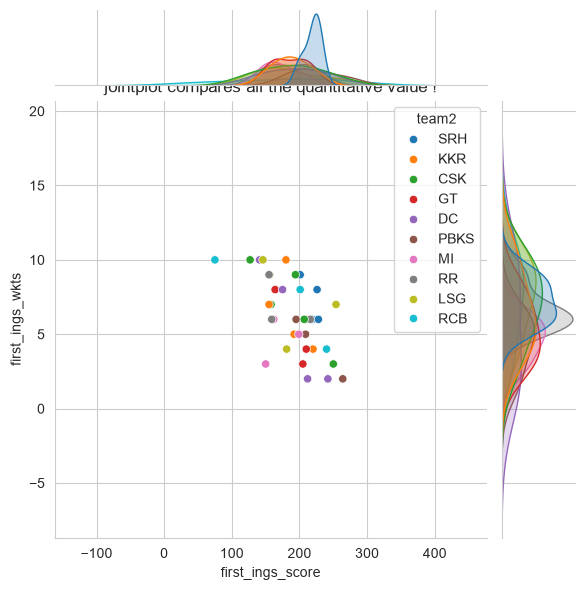

In [175]:
sns.jointplot(y='first_ings_wkts',x='first_ings_score',data=df,hue='team2')
plt.title('jointplot compares all the quantitative value !')

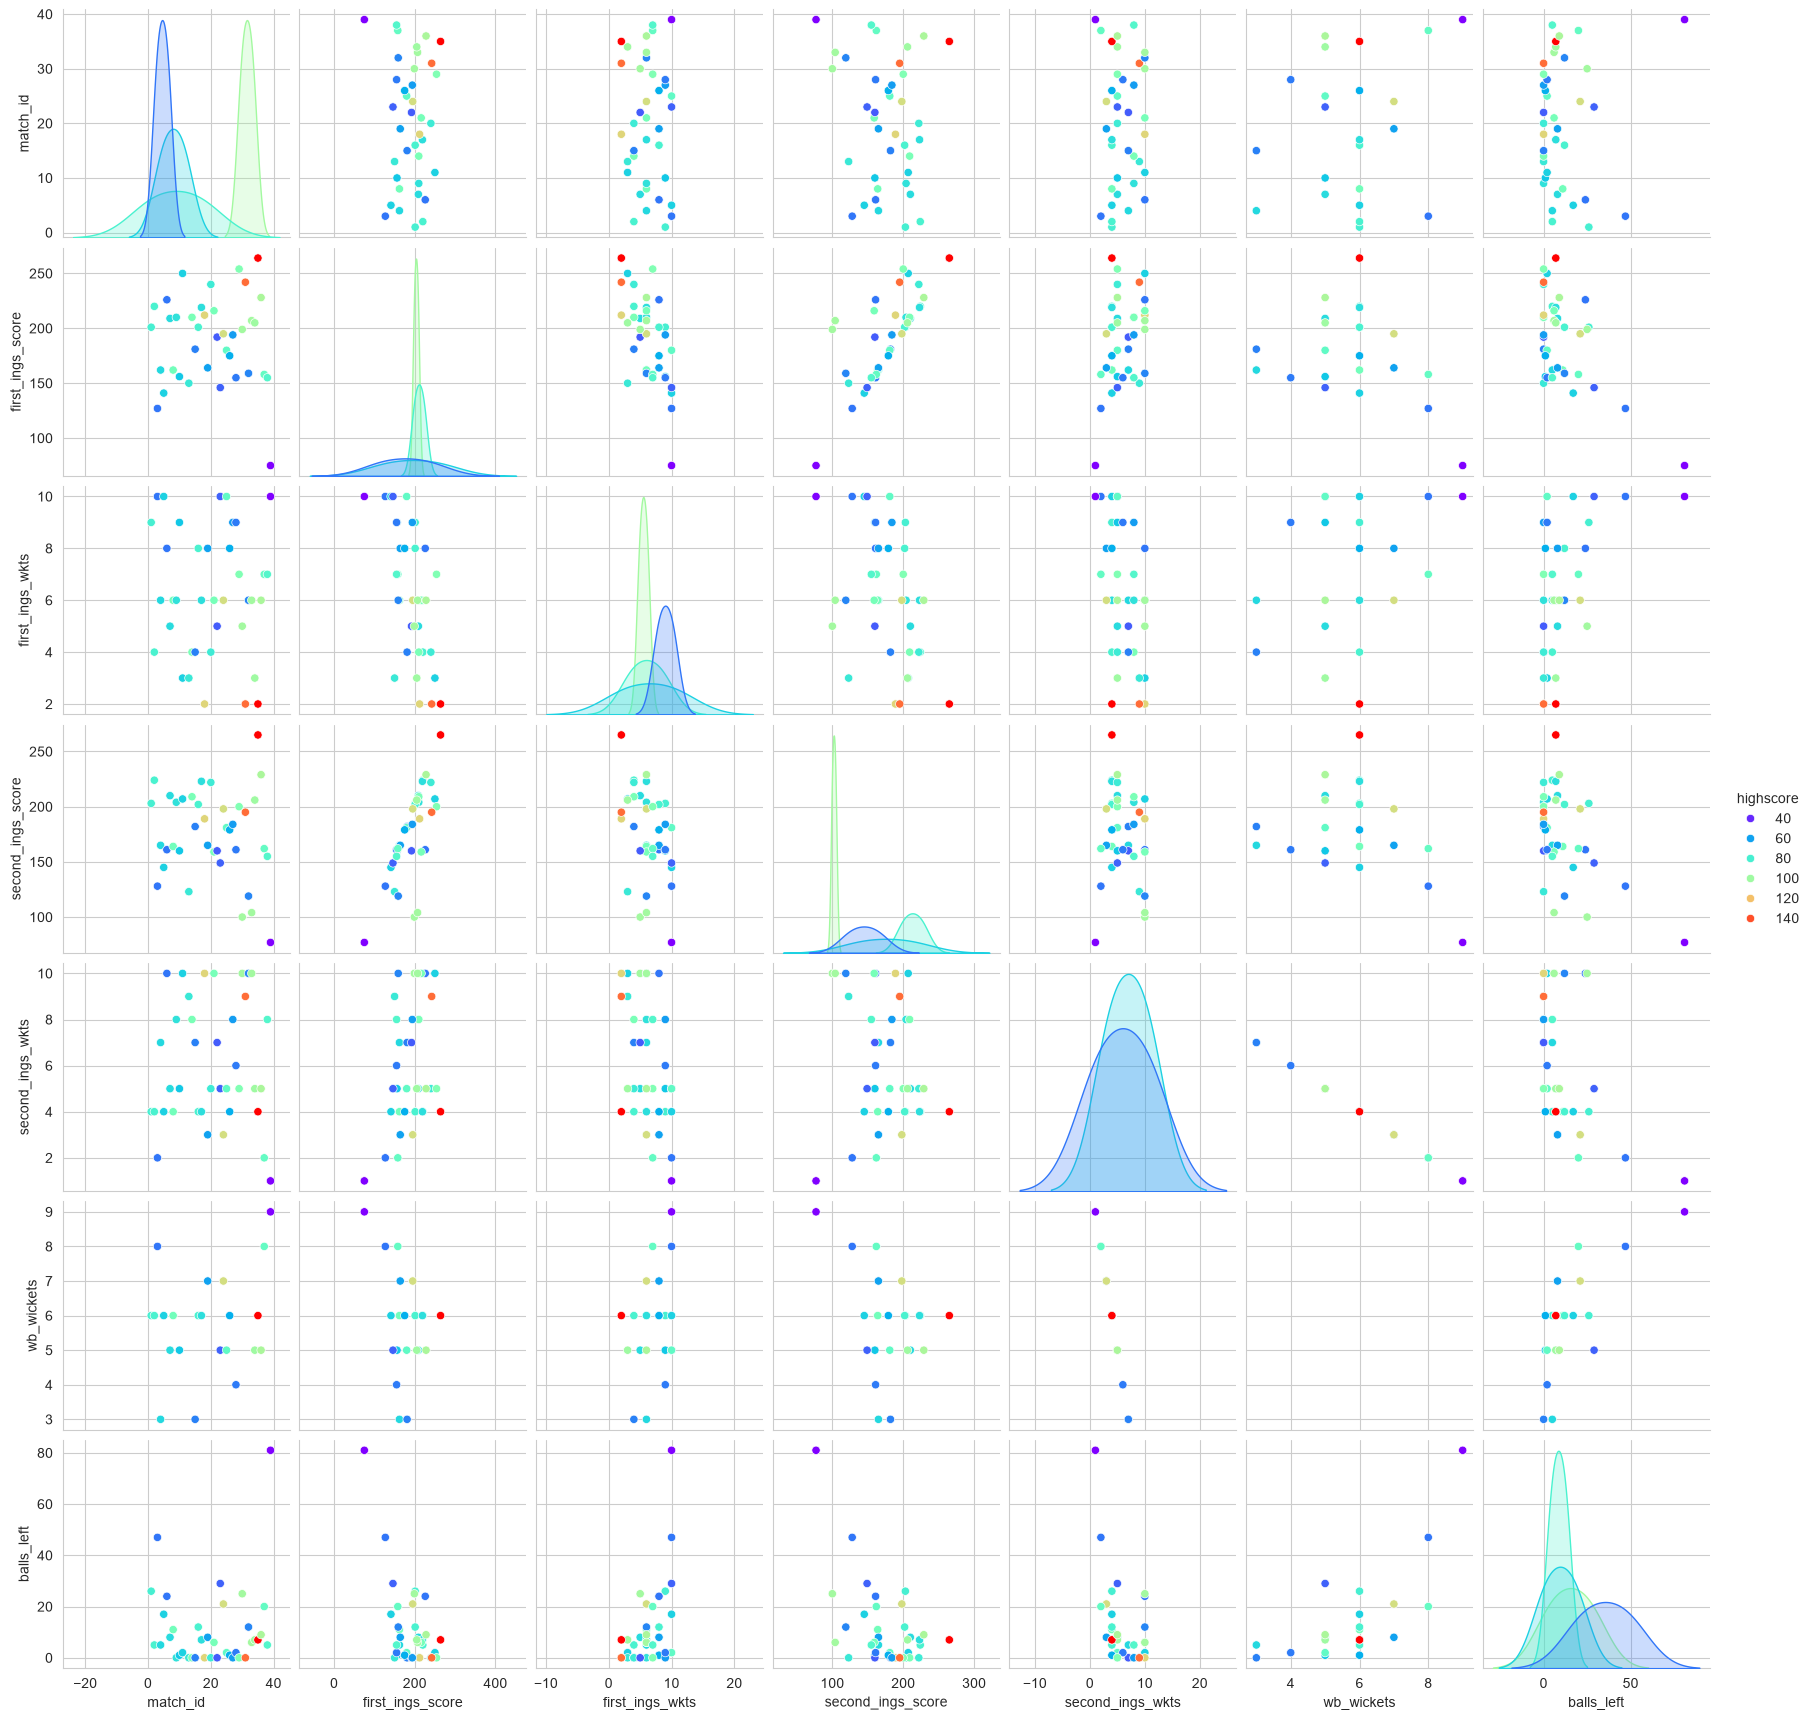

In [173]:
sns.pairplot(df,hue='highscore',palette='rainbow')

**applied categorical plot to show the qualitative  data**

<Axes: xlabel='team1', ylabel='count'>

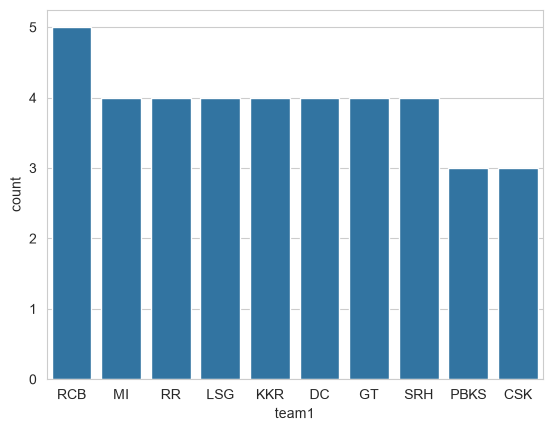

In [184]:

sns.countplot(data=df,x='team1',order=df['team1'].value_counts().index)

<Axes: xlabel='toss_winner', ylabel='match_winner'>

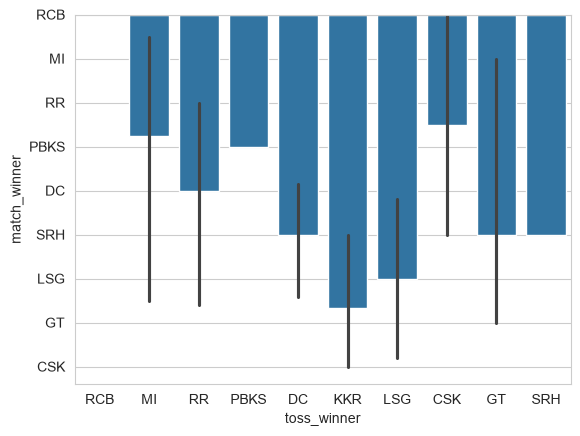

In [186]:
sns.barplot(data=df,x='toss_winner',y='match_winner')

<Axes: xlabel='toss_winner', ylabel='match_winner'>

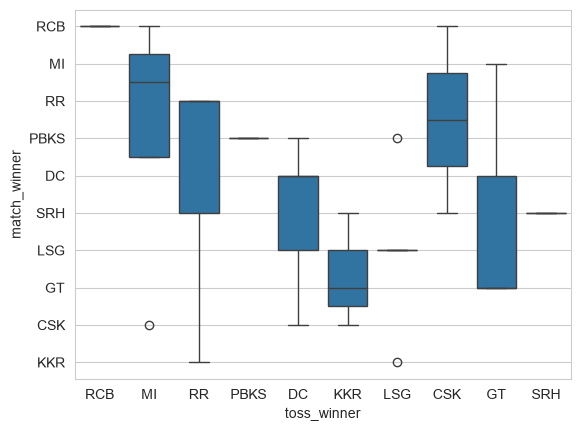

In [187]:
sns.boxplot(data=df,x='toss_winner',y='match_winner')

<Axes: xlabel='toss_winner', ylabel='match_winner'>

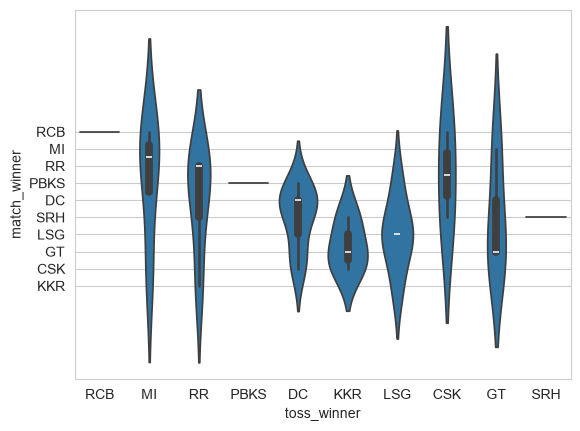

In [188]:
sns.violinplot(data=df,x='toss_winner',y='match_winner')

<Axes: xlabel='toss_winner', ylabel='match_winner'>

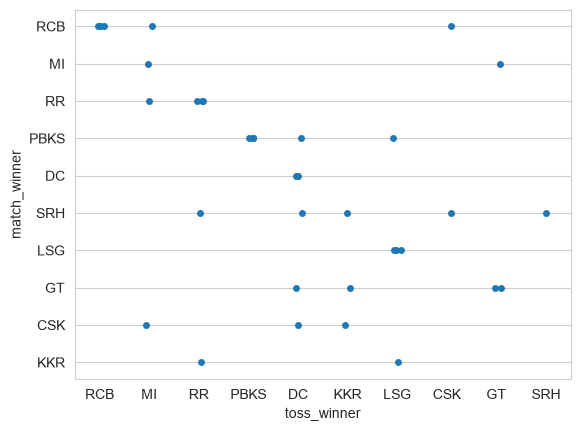

In [189]:
sns.stripplot(data=df,x='toss_winner',y='match_winner')

<Axes: xlabel='match_winner', ylabel='toss_winner'>

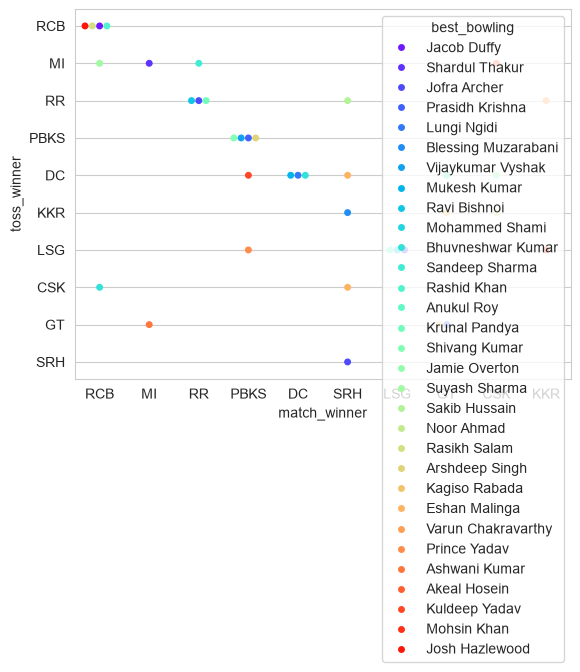

In [198]:
sns.swarmplot(data=df,y='toss_winner',x='match_winner',hue='best_bowling',palette='rainbow')

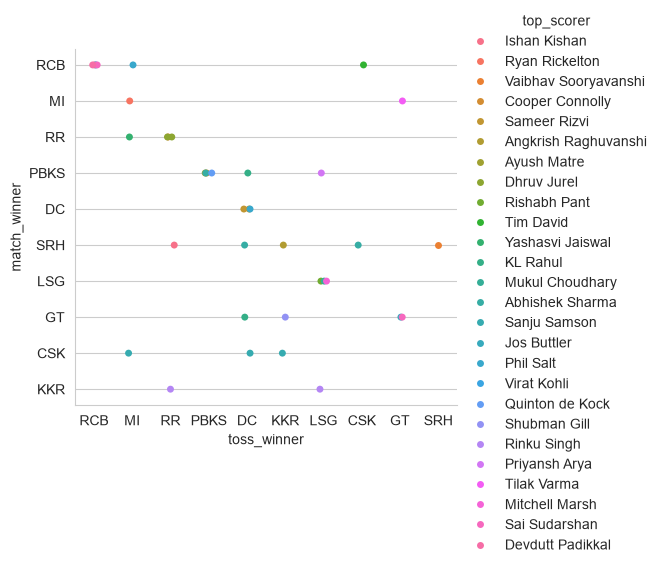

In [194]:
sns.catplot(data=df,x='toss_winner',y='match_winner',hue='top_scorer')

In [199]:
df.head(2)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_result,match_winner,wb_wickets,balls_left,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,super_over_match
0,1,"March 28, 2026","M. Chinnaswamy Stadium, Bangalore",RCB,SRH,League,RCB,Bowl,201.0,9.0,...,completed,RCB,6.0,26.0,Jacob Duffy,Ishan Kishan,80.0,Jacob Duffy,3--22,No
1,2,"March 29, 2026","Wankhede Stadium, Mumbai",MI,KKR,League,MI,Bowl,220.0,4.0,...,completed,MI,6.0,5.0,Shardul Thakur,Ryan Rickelton,81.0,Shardul Thakur,3--39,No


**using heatmap to compare the numerical values in the data frame**

In [206]:
corr=df[['first_ings_score','highscore']]

<Axes: >

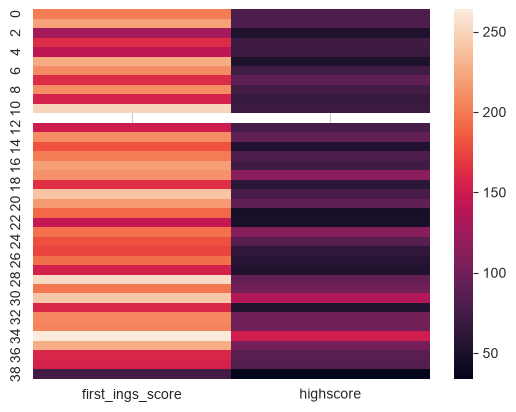

In [208]:
sns.heatmap(corr)

<Axes: >

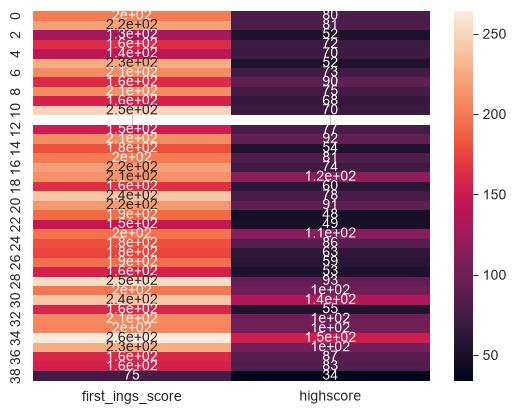

In [209]:
sns.heatmap(corr,annot=True)

***summary of all the data combined***

**there were the basice libraries of the python for machine learnig**